In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px
import numpy as np

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import posterior_function_draws, prediction_basis
from non_parametric_pro.gp import _full_gp_basis
from non_parametric_pro.adaptation.parameter_adaptation import cross_validated_parameter_adaptation
from blackjax.util import run_inference_algorithm

jax.config.update("jax_enable_x64", True)

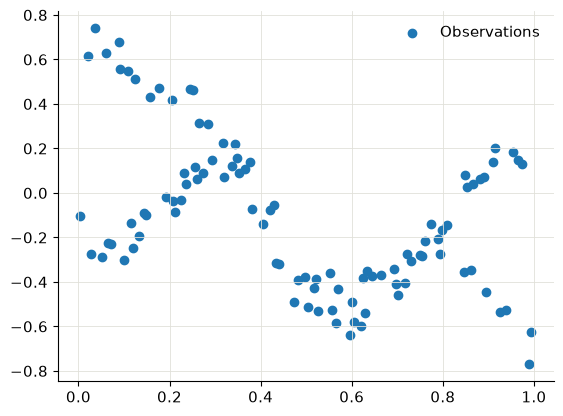

In [53]:
x = np.loadtxt("../data/multimodal_export/x_train.csv")
y = np.loadtxt("../data/multimodal_export/y_train.csv")

train_idx = np.random.choice(len(x), 100, replace=False)
train_idx = np.sort(train_idx)

x_train = x[train_idx].reshape(-1, 1)
y_train = y[train_idx].reshape(-1, 1)

x_test = x[~np.isin(np.arange(len(x)), train_idx)].reshape(-1, 1)
y_test = y[~np.isin(np.arange(len(x)), train_idx)].reshape(-1, 1)

key = jr.PRNGKey(1)

fig, ax = plt.subplots()
ax.scatter(x_train, y_train, label="Observations")
ax.legend(loc="best")
plt.show()

In [54]:
data = gpx.Dataset(X=x_train, y=y_train)
kernel = gpx.kernels.Matern32(variance=px.NonTrainable(jnp.array(1.0)))
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

optim = ox.adam(learning_rate=0.01)

gp_posterior, _ = gpx.fit(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
    optim=optim,
    num_iters=500,
    verbose=False,
)

gp_latent_dist = gp_posterior.predict(x_train, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

In [65]:
J = 30
M = data.n
sigma = gpx.parameters.SigmoidBounded(px.unwrap(gp_sigma), low=0.06, high=100.0)
basis = _full_gp_basis(gp_posterior, x_train, jitter=1e-5)

pro_params = ProParameters(
    y=data.y,
    basis=basis,
    step_size=0.00005,
    sigma=sigma,
    alpha=0.8,
    tolerance=1e-300,
    jitter=1e-6,
)

initial_position = jr.normal(key, (M, J))

adaptation = cross_validated_parameter_adaptation(
    ula,
    pro_logdensity_fn,
    pro_params,
    x_full=x_train,
    y_full=y_train,
    initial_kernel=gp_kernel,
    num_folds=1,
    val_fraction=0.5,
    num_particles=J,
    num_steps=5000,
    warmup_steps=200,
    sigma_adapt_every=10,
    kernel_adapt_every=-1,
    objective_fn=pro_logdensity_fn,
    sigma_optimizer=ox.adam(1e-1),
    kernel_optimizer=ox.adam(1e-2),
    progress_bar=True,
    rng_key=key
) 

pro_params = pro_params._replace(sigma=adaptation.sigma)
pro_kernel = adaptation.kernel
adaptation_basis = jnp.linalg.cholesky(pro_kernel.gram(x_train).as_matrix() + pro_params.jitter * jnp.eye(M))
pro_params = pro_params._replace(basis=adaptation_basis)

Running parameter adaptation


<div><progress max="5000" value="5000"></progress> 100.00% [5000/5000 00:00&lt;?]</div>

In [66]:
print(f"Adapted sigma: {pro_params.sigma}")

Adapted sigma: 0.060748490536663785


<div><progress max="40000" value="40000"></progress> 100.00% [40000/40000 00:00&lt;?]</div>

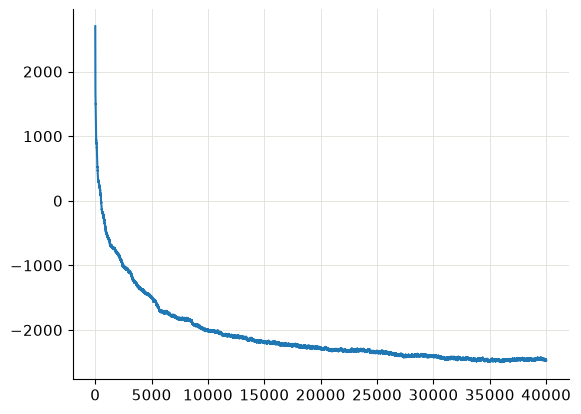

In [67]:
algorithm = parametric_ula(pro_logdensity_fn, pro_params)

initial_position = jr.normal(key, (M, J))
num_steps = 40000

_, (states, info) = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=algorithm,
    num_steps=num_steps,
    initial_position=initial_position,
    progress_bar=True
)

plt.plot(-info.score)
plt.show()

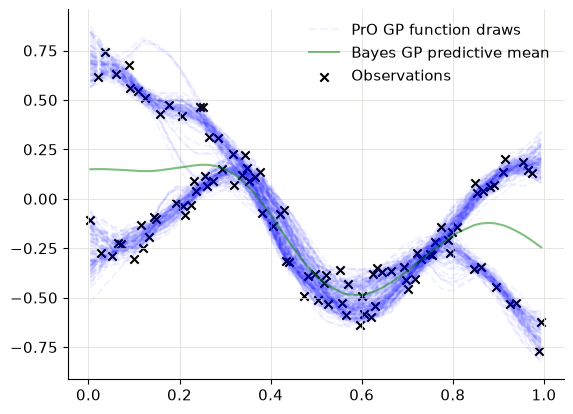

In [68]:
burn_ratio = 0.9
thin = 30

burn = int(burn_ratio * num_steps)
particles = states.position[burn::thin]

test_basis, test_cov = prediction_basis(pro_kernel, x_train, x_train, pro_params)

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    particles,
    num_draws=200,
    jitter=pro_params.jitter,
)

x_plot = x_train.squeeze()

plt.plot(x_plot, draws[:, 0], color="blue", alpha=0.05, label="PrO GP function draws", linestyle="--")
plt.plot(x_plot, draws[:, 1:], color="blue", alpha=0.05, linestyle="--")
plt.plot(x_plot, gp_predictive_mean, color="green", alpha=0.5, label="Bayes GP predictive mean")
plt.scatter(x_train.squeeze(), y_train.squeeze(), color="black", label="Observations", marker="x")
plt.legend()
plt.show()

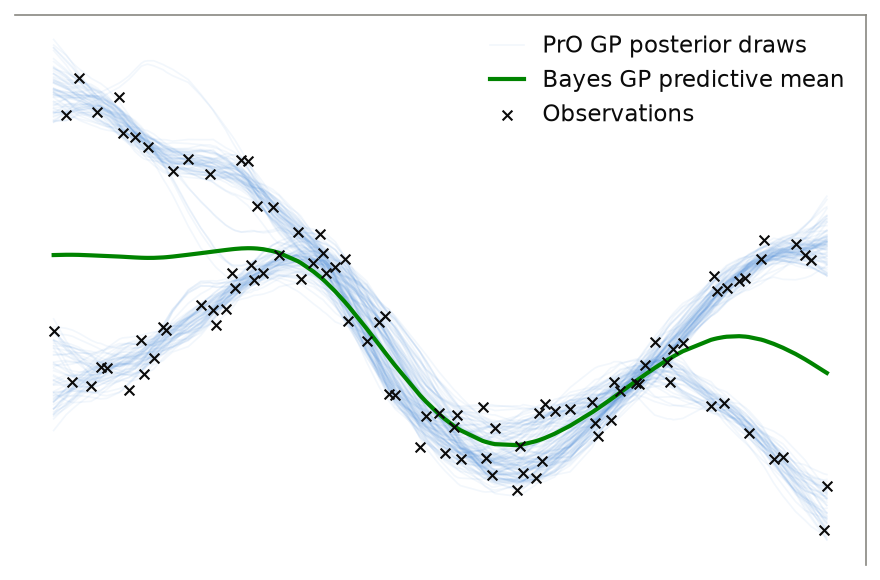

In [74]:
burn_ratio = 0.9
thin = 30

burn = int(burn_ratio * num_steps)
particles = states.position[burn::thin]

test_basis, test_cov = prediction_basis(pro_kernel, x_train, x_train, pro_params)

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    particles,
    num_draws=120,
    jitter=pro_params.jitter,
)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

draw_color = "#2a78d6"
mean_color = "#008300"
obs_color = "#0b0b0b"

order = np.argsort(x_train.squeeze())
x_sorted = x_train.squeeze()[order]
y_sorted = y_train.squeeze()[order]
mean_sorted = np.asarray(gp_predictive_mean).squeeze()[order]
draws_sorted = np.asarray(draws)[order]

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.plot(x_sorted, draws_sorted[:, 0], color=draw_color, alpha=0.06, linewidth=0.8,
        label="PrO GP posterior draws", rasterized=True)
ax.plot(x_sorted, draws_sorted[:, 1:], color=draw_color, alpha=0.06, linewidth=0.8,
        rasterized=True)
ax.plot(x_sorted, mean_sorted, color=mean_color, linewidth=2.0,
        label="Bayes GP predictive mean")
ax.scatter(x_sorted, y_sorted, color=obs_color, marker="x", s=22, linewidths=1.0,
           label="Observations", zorder=5)

ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="best", handlelength=1.5)
fig.tight_layout()
plt.show()

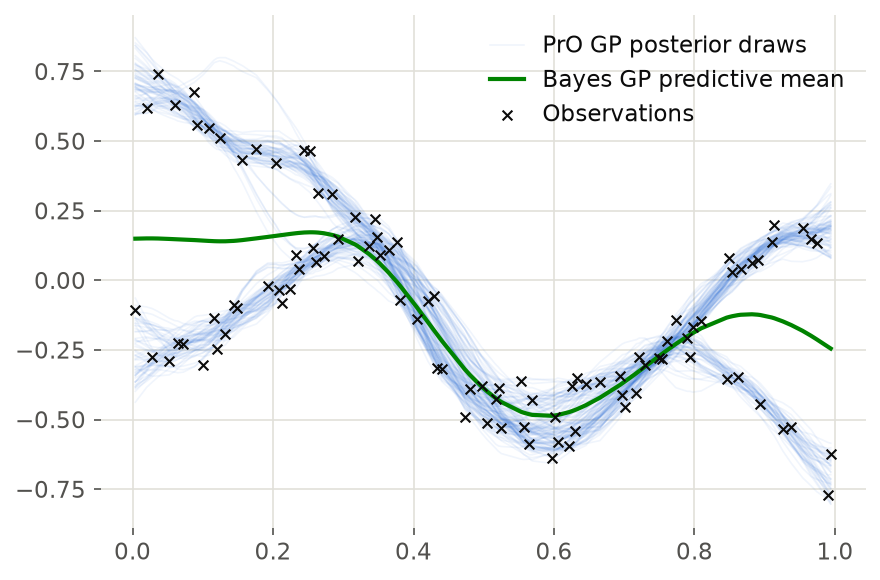

In [76]:
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#898781",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "legend.frameon": False,
})

draw_color = "#0e5ad5"
mean_color = "#008300"
obs_color = "#0b0b0b"

order = np.argsort(x_train.squeeze())
x_sorted = x_train.squeeze()[order]
y_sorted = y_train.squeeze()[order]
mean_sorted = np.asarray(gp_predictive_mean).squeeze()[order]
draws_sorted = np.asarray(draws)[order]

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.plot(x_sorted, draws_sorted[:, 0], color=draw_color, alpha=0.06, linewidth=0.8,
        label="PrO GP posterior draws", rasterized=True)
ax.plot(x_sorted, draws_sorted[:, 1:], color=draw_color, alpha=0.06, linewidth=0.8,
        rasterized=True)
ax.plot(x_sorted, mean_sorted, color=mean_color, linewidth=2.0,
        label="Bayes GP predictive mean")
ax.scatter(x_sorted, y_sorted, color=obs_color, marker="x", s=22, linewidths=1.0,
           label="Observations", zorder=5)
ax.legend(loc="best", handlelength=1.5)
fig.tight_layout()
plt.show()